# Laboratoria 11

In [1]:
import torch
import math
from torchvision.datasets import CIFAR10
import torchvision.transforms as T
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import ViTForImageClassification

In [2]:
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

train_ds = CIFAR10(
    root='data',
    train=True,
    download=True,
    transform=transform_train)

test_ds = CIFAR10(
    root='data',
    train=False,
    download=True,
    transform=transform_test)

train_dl = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True)

test_dl = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True)

Files already downloaded and verified
Files already downloaded and verified


## Sieci konwolucyjne

In [3]:
class CNN(nn.Module):
  def __init__(self, out_features, kernel_size, channels_list, ifStride, input_size=(32, 32)):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("in_conv", torch.nn.Conv2d(in_channels=3, out_channels=channels_list[0], kernel_size=1, padding=0))
    self.model.add_module("relu_1", torch.nn.ReLU())

    in_chan = channels_list[0]
    for i, out_chan in enumerate(channels_list):
      pad = kernel_size // 2
      if ifStride:
        self.model.add_module(f"conv_{i+1}", nn.Conv2d(in_channels=in_chan, out_channels=out_chan, kernel_size=kernel_size, stride=2, padding=pad))
        self.model.add_module(f"relu_{i+1}", nn.ReLU())
      else:
        self.model.add_module(f"conv_{i+1}", nn.Conv2d(in_channels=in_chan, out_channels=out_chan, kernel_size=kernel_size, stride=1, padding=pad))
        self.model.add_module(f"relu_{i+1}", nn.ReLU())
        self.model.add_module(f"max_pool_{i+1}", nn.MaxPool2d(kernel_size=2, stride=2))
      in_chan = out_chan

    num_layers = len(channels_list)
    img_h, img_w = input_size
    final_h = img_h // (2 ** num_layers)
    final_w = img_w // (2 ** num_layers)

    linear_in_features = channels_list[-1] * final_h * final_w
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", nn.Linear(in_features=linear_in_features, out_features=out_features))

  def forward(self,x):
    return self.model(x)

## Vision Transformer (VIT)

In [4]:
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def scaled_dot_product_attention(self, Q, K, V):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_probs = F.softmax(attn_scores, dim=-1)
        self.last_attn_probs = attn_probs
        output = torch.matmul(attn_probs, V)
        return output

    def forward(self, query: torch.Tensor, key: torch.Tensor, value: torch.Tensor) -> torch.Tensor:
        batch_size = query.size(0)

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        attn_output = self.scaled_dot_product_attention(Q, K, V)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(attn_output)

        return output

In [6]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 2*d_model)
        self.fc2 = nn.Linear(2*d_model, d_model)
        self.gelu = nn.GELU()   # użycie GELU

    def forward(self, x):
        return self.fc2(self.gelu(self.fc1(x)))

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        P_temp = torch.zeros((1, max_len, d_model))
        X = (torch.arange(max_len, dtype=torch.float32).reshape(-1, 1)
             / torch.pow(10000, torch.arange(0, d_model, 2, dtype=torch.float32) / d_model))
        P_temp[:, :, 0::2] = torch.sin(X)
        P_temp[:, :, 1::2] = torch.cos(X)

        self.register_buffer('P', P_temp)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :]
        return self.dropout(X)

In [8]:
class EncoderLayers(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1. Pre-LayerNorm dla mechanizmu uwagi
        nx = self.norm1(x)
        attn_output = self.self_attn(nx, nx, nx)
        x = x + self.dropout(attn_output) # Połączenie rezydualne (dodajemy do nie-znormalizowanego wejścia)

        # 2. Pre-LayerNorm dla Feed-Forward (MLP)
        nx2 = self.norm2(x)
        ff_output = self.feed_forward(nx2)
        x = x + self.dropout(ff_output)   # Połączenie rezydualne

        return x

In [9]:
class ViTEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768, dropout=0.1):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_encoder = PositionalEncoding(d_model=embed_dim, dropout=dropout, max_len=self.num_patches + 1)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                         # (B, D, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)                # (B, N, D)

        cls_tokens = self.cls_token.expand(B, -1, -1)   # (B, 1, D)
        x = torch.cat((cls_tokens, x), dim=1)           # (B, N+1, D)

        x = self.pos_encoder(x)
        return x                                        # (B, N+1, D)

In [10]:
class ViTTransformer(nn.Module):
    def __init__(self, num_classes=10, num_layers=12, img_size=224, patch_size=16, in_channels=3, embed_dim=768, num_heads=12, dropout=0.1):
        super().__init__()

        self.embedding = ViTEmbedding(img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim, dropout=dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderLayers(d_model=embed_dim, num_heads=num_heads, dropout=dropout) for _ in range(num_layers)
        ])

        # ZMIANA: Ostateczna normalizacja przed klasyfikacją (opisana w artykule)
        self.final_norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)  # (B, N+1, D)

        for encoder in self.encoder_layers:
            x = encoder(x)

        cls_token = x[:, 0]
        # Normalizacja tokenu CLS i przekazanie do klasyfikatora
        cls_token = self.final_norm(cls_token)
        return self.classifier(cls_token)

## Early Convolution in VIT

In [11]:
class Conv2DNormAct(nn.Module):
    def __init__(self, in_chan: int, out_chan: int, kernel: int, stride: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_chan, out_chan, kernel, stride, padding=1, bias=False),
            nn.BatchNorm2d(out_chan),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

In [12]:
class EarlyConvStem(nn.Module):
    def __init__(self, in_channels=3, embed_dim=768):
        super().__init__()

        self.stem = nn.Sequential(
            Conv2DNormAct(in_channels, 64, kernel=3, stride=2),
            Conv2DNormAct(64, 128, kernel=3, stride=2),
            Conv2DNormAct(128, 128, kernel=3, stride=1),
            Conv2DNormAct(128, 256, kernel=3, stride=2),
            Conv2DNormAct(256, 256, kernel=3, stride=1),
            Conv2DNormAct(256, 512, kernel=3, stride=2),
            nn.Conv2d(512, embed_dim, kernel_size=1, stride=1)
        )

    def forward(self, x):
        return self.stem(x)

In [13]:
class ViTEarlyConvTransformer(nn.Module):
    def __init__(self, num_classes=10, num_layers=12, img_size=224, patch_size=16, in_channels=3, embed_dim=768, num_heads=12, dropout=0.1):
        super().__init__()

        self.num_patches = (img_size // patch_size) ** 2

        # Wstawiamy nasz EarlyConvStem zamiast pojedynczej dużej konwolucji
        self.embedding_stem = EarlyConvStem(in_channels=in_channels, embed_dim=embed_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional Encoding dla N_patchy + 1 (dla CLS token)
        self.pos_encoder = PositionalEncoding(d_model=embed_dim, dropout=dropout, max_len=self.num_patches + 1)

        self.encoder_layers = nn.ModuleList([
            EncoderLayers(d_model=embed_dim, num_heads=num_heads, dropout=dropout) for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.embedding_stem(x)                     # (B, embed_dim, H/16, W/16)

        # 2. Flatten i Transpose, aby uzyskać sekwencję tokenów
        x = x.flatten(2).transpose(1, 2)               # (B, num_patches, embed_dim)

        # 3. Dodanie tokenu CLS
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)          # (B, num_patches+1, embed_dim)

        # 4. Dodanie Positional Encoding
        x = self.pos_encoder(x)

        for encoder in self.encoder_layers:
            x = encoder(x)

        cls_token = x[:, 0]
        # Normalizacja tokenu CLS i przekazanie do klasyfikatora
        cls_token = self.final_norm(cls_token)
        return self.classifier(cls_token)

## Trenowanie modeli

In [14]:
def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> tuple[float, float]:
    loss = 0
    correct = 0
    all = 0
    for X_batch, y_batch in dataloader:
        X_batch_cuda = X_batch.cuda()
        y_batch_cuda = y_batch.cuda()

        y_pred = model(X_batch_cuda)
        batch_size = len(y_pred)
        all += batch_size

        loss += loss_fn(y_pred, y_batch_cuda).item() * batch_size
        correct += count_correct(y_pred, y_batch_cuda)
    return loss / all, float(correct) / all

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: bool = True
):
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
  scaler = torch.amp.GradScaler('cuda')

  for epoch in range(epochs):
      model.train()
      for X_batch, y_batch in tqdm(train_dl):
            X_batch_cuda = X_batch.cuda()
            y_batch_cuda = y_batch.cuda()

            with torch.amp.autocast(device_type='cuda'):
                y_pred = model(X_batch_cuda)
                loss = loss_fn(y_pred, y_batch_cuda)

            scaler.scale(loss).backward()

            scaler.unscale_(optimiser)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimiser)
            scaler.update()
            optimiser.zero_grad()

      if print_metrics:
          model.eval()
          with torch.no_grad():
              train_loss, train_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=train_dl
              )
              val_loss, val_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=val_dl
              )
              history['train_loss'].append(train_loss)
              history['train_acc'].append(train_acc)
              history['val_loss'].append(val_loss)
              history['val_acc'].append(val_acc)
  return history

def plot_metrixes(all_histories):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    ax_train_loss = axes[0, 0]
    ax_val_loss = axes[0, 1]
    ax_train_acc = axes[1, 0]
    ax_val_acc = axes[1, 1]

    for name, hist in all_histories.items():
        train_loss = [float(x) for x in hist['train_loss']]
        val_loss = [float(x) for x in hist['val_loss']]
        train_acc = [float(x) for x in hist['train_acc']]
        val_acc = [float(x) for x in hist['val_acc']]

        ax_train_loss.plot(train_loss, label=name, linewidth=2)
        ax_val_loss.plot(val_loss, label=name, linewidth=2, linestyle='--')

        ax_train_acc.plot(train_acc, label=name, linewidth=2)
        ax_val_acc.plot(val_acc, label=name, linewidth=2, linestyle='--')

    ax_train_loss.set_title("Train Loss")
    ax_train_loss.set_xlabel("Epoch")
    ax_train_loss.set_ylabel("Loss")
    ax_train_loss.legend()
    ax_train_loss.grid(True, linestyle=':', alpha=0.6)

    ax_val_loss.set_title("Validation Loss")
    ax_val_loss.set_xlabel("Epoch")
    ax_val_loss.set_ylabel("Loss")
    ax_val_loss.legend()
    ax_val_loss.grid(True, linestyle=':', alpha=0.6)

    ax_train_acc.set_title("Train Accuracy")
    ax_train_acc.set_xlabel("Epoch")
    ax_train_acc.set_ylabel("Accuracy")
    ax_train_acc.legend()
    ax_train_acc.grid(True, linestyle=':', alpha=0.6)

    ax_val_acc.set_title("Validation Accuracy")
    ax_val_acc.set_xlabel("Epoch")
    ax_val_acc.set_ylabel("Accuracy")
    ax_val_acc.legend()
    ax_val_acc.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


CNN


100%|██████████| 1563/1563 [00:55<00:00, 28.16it/s]



VIT_base


100%|██████████| 1563/1563 [02:16<00:00, 11.43it/s]



VIT_Early_Conv


100%|██████████| 1563/1563 [02:24<00:00, 10.80it/s]


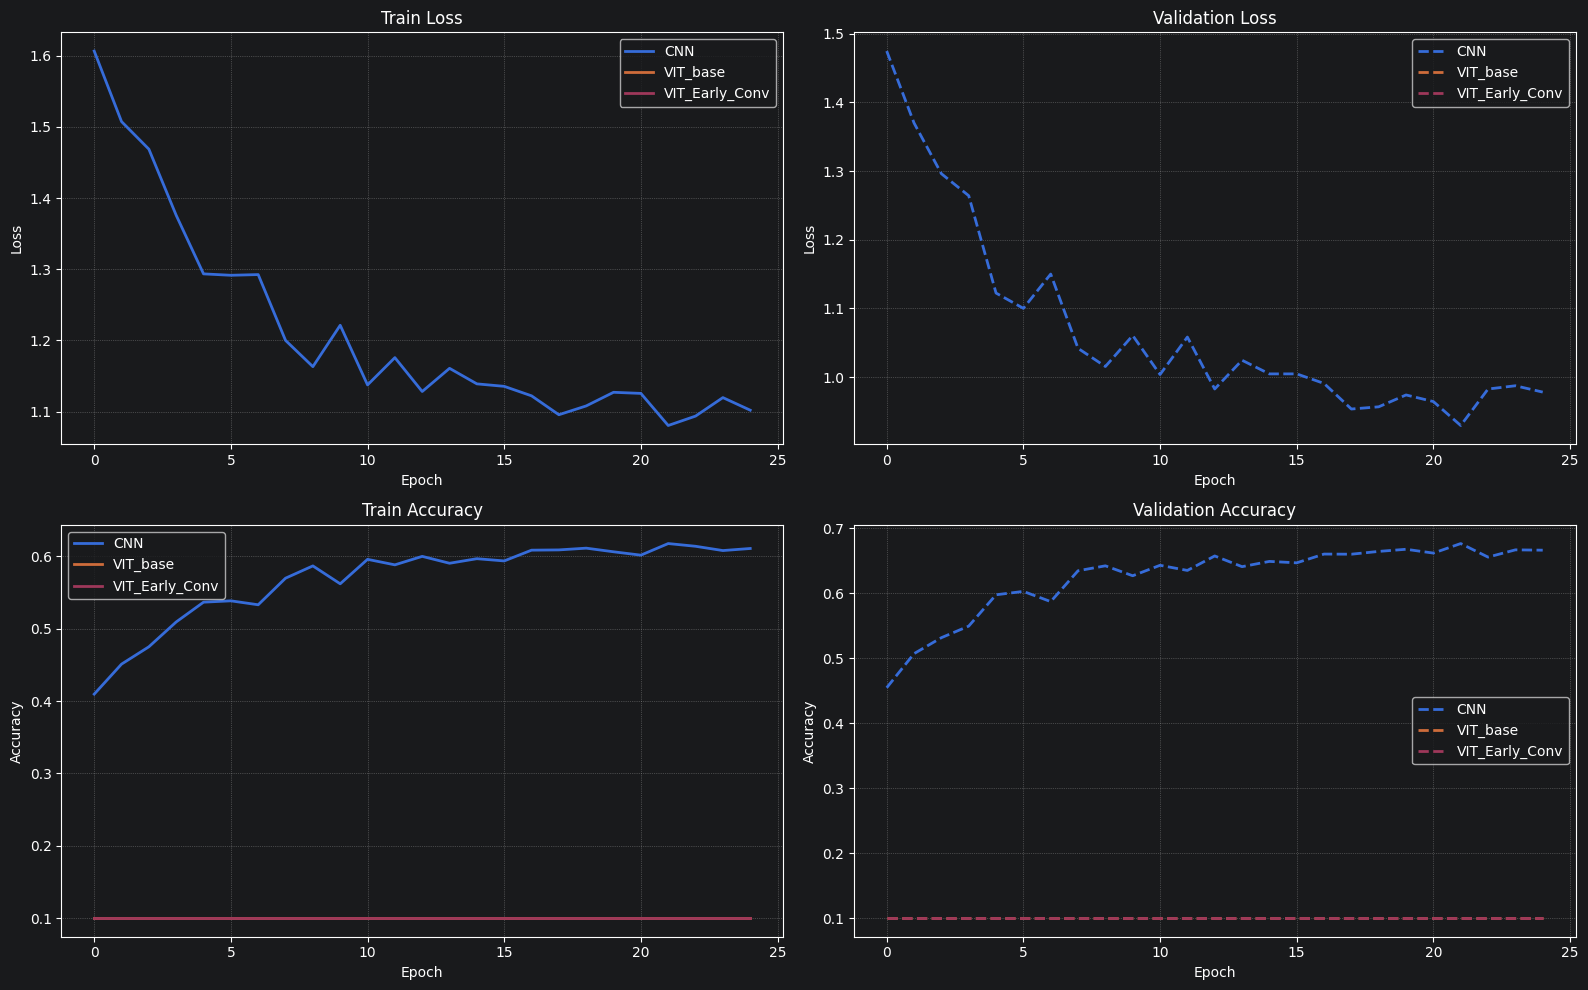

In [15]:
configs = {
    "CNN": (
        CNN(10, 3, [16, 32, 64], False).cuda()
    ),
    "VIT_base": (
        ViTTransformer().cuda()
    ),
    "VIT_Early_Conv": (
        ViTEarlyConvTransformer().cuda()
    ),
}

all_histories = {}
torch.cuda.empty_cache()

for name, model in configs.items():
    print(f"\n{name}")
    model = model.cuda()

    loss = torch.nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=3e-3)

    history = fit(model, optimizer, loss, train_dl, test_dl, epochs=25)
    all_histories[name] = history

plot_metrixes(all_histories)